# FPOI V7.5 — PROTEAS G0–G5 post-diagnostic final rerun

This notebook is the final real-archive rerun notebook.

## Integrity model

The audit implementation is **not embedded in the notebook**. The notebook loads
`proteas_target_pairing_audit_v6.py` and `gates_v4_postdiagnostic_clean.json` from Google Drive
(or from the final bundle ZIP stored in Drive), verifies both SHA-256 values, compiles the audit
script, and only then proceeds to archive analysis.

Audit script SHA-256:

`79672a02f16e0e65a86c421829868afd372ce210fbb770d004c67fc45ad09906`

Authoritative gate configuration SHA-256:

`2ae7ecaf8611da2cfb546f5ac4410f95234b542009aa01220f0b7fc9dfc8be18`

G5 artifact SHA-256:

`68b9408bceb7100e3f7bc26473269db30fb6eefb9bd06d669902b1e8a40847bf`


In [4]:
# Install only the libraries needed by the frozen audit.
!pip -q install pandas numpy scipy nibabel pydicom openpyxl

from pathlib import Path
import os, re, json, zipfile, shutil, hashlib, subprocess
import numpy as np
import pandas as pd
import pydicom

from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
DRIVE_ROOT = Path("/content/drive/MyDrive/FPOI_DATA")
PROTEAS_DRIVE = DRIVE_ROOT / "PROTEAS"
RESULTS_DRIVE = DRIVE_ROOT / "RESULTS" / "PROTEAS_G0_G5_POSTDIAGNOSTIC_FINAL"

# Put this ZIP anywhere under DRIVE_ROOT, or place the individual script/config
# files under DRIVE_ROOT/PROTEAS.
FINAL_BUNDLE_ZIP = DRIVE_ROOT / "FPOI_V7_5_POSTDIAGNOSTIC_FINAL_BUNDLE_FIXED.zip"

CORRECTED_GATES_GIT_COMMIT = "not-yet-committed; post-diagnostic corrected gate set"

EXPECTED_AUDIT_SCRIPT_SHA256 = "79672a02f16e0e65a86c421829868afd372ce210fbb770d004c67fc45ad09906"
EXPECTED_GATES_SHA256 = "2ae7ecaf8611da2cfb546f5ac4410f95234b542009aa01220f0b7fc9dfc8be18"
EXPECTED_G5_SHA256 = "68b9408bceb7100e3f7bc26473269db30fb6eefb9bd06d669902b1e8a40847bf"

G5_QA_PATH = PROTEAS_DRIVE / "lesion_correspondence_QA.csv"

RESULTS_DRIVE.mkdir(parents=True, exist_ok=True)

print("Audit script SHA-256:", EXPECTED_AUDIT_SCRIPT_SHA256)
print("Gate config SHA-256:", EXPECTED_GATES_SHA256)
print("G5 artifact SHA-256:", EXPECTED_G5_SHA256)


Audit script SHA-256: 79672a02f16e0e65a86c421829868afd372ce210fbb770d004c67fc45ad09906
Gate config SHA-256: 2ae7ecaf8611da2cfb546f5ac4410f95234b542009aa01220f0b7fc9dfc8be18
G5 artifact SHA-256: 68b9408bceb7100e3f7bc26473269db30fb6eefb9bd06d669902b1e8a40847bf


## 1. Materialize the frozen audit implementation

The exact patched audit script and gate configuration are written from this notebook into the Colab working directory. The gate file is hash-checked before any archive result is inspected.


In [6]:
WORK = Path("/content/FPOI_V75_G0_G5_POSTDIAGNOSTIC_FINAL")
DATA = WORK / "data"
OUT = WORK / "results"
TOOLS = WORK / "tools"
BUNDLE_EXTRACT = WORK / "bundle_extract"

for d in [WORK, DATA, OUT, TOOLS, BUNDLE_EXTRACT]:
    d.mkdir(parents=True, exist_ok=True)

AUDIT_SCRIPT = TOOLS / "proteas_target_pairing_audit_v6.py"
GATES_FILE = TOOLS / "gates_v4_postdiagnostic_clean.json"

def first_existing(paths):
    for p in paths:
        if p is not None and Path(p).exists():
            return Path(p)
    return None

script_candidates = [
    DRIVE_ROOT / "proteas_target_pairing_audit_v6.py",
    PROTEAS_DRIVE / "proteas_target_pairing_audit_v6.py",
]
config_candidates = [
    DRIVE_ROOT / "gates_v4_postdiagnostic_clean.json",
    PROTEAS_DRIVE / "gates_v4_postdiagnostic_clean.json",
]

script_src = first_existing(script_candidates)
config_src = first_existing(config_candidates)

if script_src is None and DRIVE_ROOT.exists():
    hits = list(DRIVE_ROOT.rglob("proteas_target_pairing_audit_v6.py"))
    script_src = hits[0] if hits else None

if config_src is None and DRIVE_ROOT.exists():
    hits = list(DRIVE_ROOT.rglob("gates_v4_postdiagnostic_clean.json"))
    config_src = hits[0] if hits else None

bundle_src = FINAL_BUNDLE_ZIP if FINAL_BUNDLE_ZIP.exists() else None
if bundle_src is None and DRIVE_ROOT.exists():
    hits = list(DRIVE_ROOT.rglob("FPOI_V7_5_POSTDIAGNOSTIC_FINAL_BUNDLE_FIXED.zip"))
    if not hits:
        hits = list(DRIVE_ROOT.rglob("FPOI_V7_5_POSTDIAGNOSTIC_FINAL_BUNDLE.zip"))
    bundle_src = hits[0] if hits else None

if (script_src is None or config_src is None) and bundle_src is not None:
    print("Loading verified files from bundle:", bundle_src)
    with zipfile.ZipFile(bundle_src, "r") as z:
        members = {Path(n).name: n for n in z.namelist()}
        needed = [
            "proteas_target_pairing_audit_v6.py",
            "gates_v4_postdiagnostic_clean.json",
        ]
        missing = [n for n in needed if n not in members]
        if missing:
            raise FileNotFoundError(f"Bundle missing required files: {missing}")
        for name in needed:
            outp = BUNDLE_EXTRACT / name
            outp.write_bytes(z.read(members[name]))

    if script_src is None:
        script_src = BUNDLE_EXTRACT / "proteas_target_pairing_audit_v6.py"
    if config_src is None:
        config_src = BUNDLE_EXTRACT / "gates_v4_postdiagnostic_clean.json"

if script_src is None:
    raise FileNotFoundError(
        "Could not locate proteas_target_pairing_audit_v6.py in Google Drive or bundle."
    )
if config_src is None:
    raise FileNotFoundError(
        "Could not locate gates_v4_postdiagnostic_clean.json in Google Drive or bundle."
    )

shutil.copy2(script_src, AUDIT_SCRIPT)
shutil.copy2(config_src, GATES_FILE)

script_sha = hashlib.sha256(AUDIT_SCRIPT.read_bytes()).hexdigest()
config_sha = hashlib.sha256(GATES_FILE.read_bytes()).hexdigest()

print("Audit script source:", script_src)
print("Audit script SHA-256:", script_sha)
print("Expected:", EXPECTED_AUDIT_SCRIPT_SHA256)
print()
print("Gate config source:", config_src)
print("Gate config SHA-256:", config_sha)
print("Expected:", EXPECTED_GATES_SHA256)

if script_sha != EXPECTED_AUDIT_SCRIPT_SHA256:
    raise RuntimeError("Audit script hash mismatch. Do not continue.")
if config_sha != EXPECTED_GATES_SHA256:
    raise RuntimeError("Gate configuration hash mismatch. Do not continue.")

compile(
    AUDIT_SCRIPT.read_text(encoding="utf-8"),
    str(AUDIT_SCRIPT),
    "exec"
)

print("\nAudit implementation and gate configuration both verified.")


Loading verified files from bundle: /content/drive/MyDrive/FPOI_DATA/FPOI_V7_5_POSTDIAGNOSTIC_FINAL_BUNDLE_FIXED.zip
Audit script source: /content/FPOI_V75_G0_G5_POSTDIAGNOSTIC_FINAL/bundle_extract/proteas_target_pairing_audit_v6.py
Audit script SHA-256: 79672a02f16e0e65a86c421829868afd372ce210fbb770d004c67fc45ad09906
Expected: 79672a02f16e0e65a86c421829868afd372ce210fbb770d004c67fc45ad09906

Gate config source: /content/FPOI_V75_G0_G5_POSTDIAGNOSTIC_FINAL/bundle_extract/gates_v4_postdiagnostic_clean.json
Gate config SHA-256: 2ae7ecaf8611da2cfb546f5ac4410f95234b542009aa01220f0b7fc9dfc8be18
Expected: 2ae7ecaf8611da2cfb546f5ac4410f95234b542009aa01220f0b7fc9dfc8be18

Audit implementation and gate configuration both verified.


## 2. Locate and extract the nine PROTEAS archives

The notebook supports either individual patient ZIP files in the PROTEAS Drive folder or a combined archive containing them.


In [7]:
ZIP_NAMES = [
    "P13.zip", "P17a.zip", "P17b.zip",
    "P23a.zip", "P23b.zip", "P31.zip",
    "P35.zip", "P37.zip", "P39.zip"
]

# First look for individual archives recursively under PROTEAS.
zip_lookup = {}
if PROTEAS_DRIVE.exists():
    for zn in ZIP_NAMES:
        hits = list(PROTEAS_DRIVE.rglob(zn))
        if hits:
            zip_lookup[zn] = hits[0]

# If needed, inspect likely combined archives.
if len(zip_lookup) < len(ZIP_NAMES):
    combined_candidates = []
    if PROTEAS_DRIVE.exists():
        combined_candidates += list(PROTEAS_DRIVE.glob("*.zip"))
    combined_candidates += [
        DRIVE_ROOT / "Proteas_Downloads.zip",
        PROTEAS_DRIVE / "Proteas_Downloads.zip",
    ]

    COMBINED = WORK / "combined"
    COMBINED.mkdir(exist_ok=True)

    for cp in combined_candidates:
        if not cp.exists():
            continue
        try:
            with zipfile.ZipFile(cp, "r") as z:
                names = set(Path(n).name for n in z.namelist())
                if any(zn in names for zn in ZIP_NAMES):
                    sub = COMBINED / cp.stem
                    sub.mkdir(exist_ok=True)
                    z.extractall(sub)
                    for zn in ZIP_NAMES:
                        hits = list(sub.rglob(zn))
                        if hits and zn not in zip_lookup:
                            zip_lookup[zn] = hits[0]
        except zipfile.BadZipFile:
            pass

missing = [zn for zn in ZIP_NAMES if zn not in zip_lookup]
if missing:
    raise FileNotFoundError(
        "Could not locate these archives in Google Drive: " + ", ".join(missing)
    )

print("Located all nine archives:")
for zn in ZIP_NAMES:
    print(" ", zn, "->", zip_lookup[zn])

for zn in ZIP_NAMES:
    archive = zn[:-4]
    dest = DATA / archive
    dest.mkdir(parents=True, exist_ok=True)
    marker = dest / ".extracted_ok"

    if not marker.exists():
        with zipfile.ZipFile(zip_lookup[zn], "r") as z:
            z.extractall(dest)
        marker.write_text("ok")
        print("Extracted:", zn)
    else:
        print("Already extracted:", zn)


Located all nine archives:
  P13.zip -> /content/drive/MyDrive/FPOI_DATA/PROTEAS/P13.zip
  P17a.zip -> /content/drive/MyDrive/FPOI_DATA/PROTEAS/P17a.zip
  P17b.zip -> /content/drive/MyDrive/FPOI_DATA/PROTEAS/P17b.zip
  P23a.zip -> /content/drive/MyDrive/FPOI_DATA/PROTEAS/P23a.zip
  P23b.zip -> /content/drive/MyDrive/FPOI_DATA/PROTEAS/P23b.zip
  P31.zip -> /content/drive/MyDrive/FPOI_DATA/PROTEAS/P31.zip
  P35.zip -> /content/drive/MyDrive/FPOI_DATA/PROTEAS/P35.zip
  P37.zip -> /content/drive/MyDrive/FPOI_DATA/PROTEAS/P37.zip
  P39.zip -> /content/drive/MyDrive/FPOI_DATA/PROTEAS/P39.zip
Extracted: P13.zip
Extracted: P17a.zip
Extracted: P17b.zip
Extracted: P23a.zip
Extracted: P23b.zip
Extracted: P31.zip
Extracted: P35.zip
Extracted: P37.zip
Extracted: P39.zip


## 3. Auto-discover RTP, RTPLAN, RTDOSE, baseline mask, and follow-up masks

Discovery is based on NIfTI filenames and DICOM modality rather than fixed folder depth.


In [8]:
def patient_root(archive_dir, archive):
    hits = [p for p in Path(archive_dir).rglob(archive) if p.is_dir()]
    return hits[0] if hits else Path(archive_dir)

def all_niftis(root):
    return sorted(list(Path(root).rglob("*.nii")) + list(Path(root).rglob("*.nii.gz")))

def discover_nifti(root, archive):
    found = {
        "rtp": None,
        "baseline": None,
        "followups": []
    }

    for p in all_niftis(root):
        n = p.name.lower()

        if n in [f"{archive.lower()}_rtp.nii", f"{archive.lower()}_rtp.nii.gz"]:
            found["rtp"] = p

        if "tumor_mask_baseline" in n or "tumour_mask_baseline" in n:
            found["baseline"] = p

        m = re.search(r"tumou?r_mask_fu(\d+)", n)
        if m:
            found["followups"].append((int(m.group(1)), p))

    found["followups"] = [
        p for _, p in sorted(found["followups"], key=lambda x: x[0])
    ]
    return found

def discover_dicom(root, modality):
    hits = []
    for f in Path(root).rglob("*"):
        if not f.is_file():
            continue
        try:
            ds = pydicom.dcmread(str(f), stop_before_pixels=True, force=True)
            if str(getattr(ds, "Modality", "")) == modality:
                hits.append(f)
        except Exception:
            pass
    return hits

discovery_rows = []
case_paths = {}

for zn in ZIP_NAMES:
    archive = zn[:-4]
    root = patient_root(DATA/archive, archive)
    nf = discover_nifti(root, archive)
    plans = discover_dicom(root, "RTPLAN")
    doses = discover_dicom(root, "RTDOSE")

    discovery_rows.append({
        "archive_id": archive,
        "rtp_nifti": str(nf["rtp"]) if nf["rtp"] else "",
        "baseline_mask": str(nf["baseline"]) if nf["baseline"] else "",
        "n_followups": len(nf["followups"]),
        "n_rtplan": len(plans),
        "n_rtdose": len(doses)
    })

    case_paths[archive] = {
        "root": root,
        "rtp": nf["rtp"],
        "baseline": nf["baseline"],
        "followups": nf["followups"],
        "rtplan": plans[0] if len(plans) == 1 else None,
        "rtdose": doses[0] if len(doses) == 1 else None,
    }

discovery_df = pd.DataFrame(discovery_rows)
display(discovery_df)

bad = discovery_df[
    discovery_df.rtp_nifti.eq("")
    | discovery_df.baseline_mask.eq("")
    | discovery_df.n_rtplan.ne(1)
    | discovery_df.n_rtdose.ne(1)
]

if len(bad):
    raise RuntimeError(
        "Automatic discovery did not uniquely identify all required files. "
        "Inspect discovery_df before continuing."
    )

observed_followups = int(discovery_df.n_followups.sum())
print(f"Discovery measurement: 9 baselines + {observed_followups} follow-up masks.")
print("The previous G5 artifact contains 29 rows; a mismatch is reported, not repaired or forced.")


/usr/local/lib/python3.13/dist-packages/pydicom/filereader.py:402: UserWarning: Expected implicit VR, but found explicit VR - using explicit VR for reading
  warn_and_log(f"{msg} - using {found_vr} VR for reading", UserWarning)


,archive_id,rtp_nifti,baseline_mask,n_followups,n_rtplan,n_rtdose
0,P13,/content/FPOI_V75_G0_G5_POSTDIAGNOSTIC_FINAL/d...,/content/FPOI_V75_G0_G5_POSTDIAGNOSTIC_FINAL/d...,5,1,1
1,P17a,/content/FPOI_V75_G0_G5_POSTDIAGNOSTIC_FINAL/d...,/content/FPOI_V75_G0_G5_POSTDIAGNOSTIC_FINAL/d...,4,1,1
2,P17b,/content/FPOI_V75_G0_G5_POSTDIAGNOSTIC_FINAL/d...,/content/FPOI_V75_G0_G5_POSTDIAGNOSTIC_FINAL/d...,5,1,1
3,P23a,/content/FPOI_V75_G0_G5_POSTDIAGNOSTIC_FINAL/d...,/content/FPOI_V75_G0_G5_POSTDIAGNOSTIC_FINAL/d...,3,1,1
4,P23b,/content/FPOI_V75_G0_G5_POSTDIAGNOSTIC_FINAL/d...,/content/FPOI_V75_G0_G5_POSTDIAGNOSTIC_FINAL/d...,4,1,1
5,P31,/content/FPOI_V75_G0_G5_POSTDIAGNOSTIC_FINAL/d...,/content/FPOI_V75_G0_G5_POSTDIAGNOSTIC_FINAL/d...,3,1,1
6,P35,/content/FPOI_V75_G0_G5_POSTDIAGNOSTIC_FINAL/d...,/content/FPOI_V75_G0_G5_POSTDIAGNOSTIC_FINAL/d...,2,1,1
7,P37,/content/FPOI_V75_G0_G5_POSTDIAGNOSTIC_FINAL/d...,/content/FPOI_V75_G0_G5_POSTDIAGNOSTIC_FINAL/d...,2,1,1
8,P39,/content/FPOI_V75_G0_G5_POSTDIAGNOSTIC_FINAL/d...,/content/FPOI_V75_G0_G5_POSTDIAGNOSTIC_FINAL/d...,1,1,1


Discovery measurement: 9 baselines + 29 follow-up masks.
The previous G5 artifact contains 29 rows; a mismatch is reported, not repaired or forced.


## 4. Resolve the clinical prescription fields

For P13, P17a/b, P23a/b, P35, P37, and P39 the exact clinical treatment-course row is used. P31 is intentionally left prescription-ambiguous because the single archive corresponds to two clinical course records (P31a/P31b) and must not be silently assigned to one.


In [9]:
clinical_candidates = [
    PROTEAS_DRIVE / "PROTEAS_clinical_readable.csv",
    PROTEAS_DRIVE / "PROTEAS-Clinical_and_demographic_data.xlsx",
]

# Also search recursively in the PROTEAS Drive folder.
if PROTEAS_DRIVE.exists():
    clinical_candidates += list(PROTEAS_DRIVE.rglob("PROTEAS_clinical_readable.csv"))
    clinical_candidates += list(PROTEAS_DRIVE.rglob("PROTEAS-Clinical_and_demographic_data.xlsx"))

clinical_path = next((p for p in clinical_candidates if p.exists()), None)
if clinical_path is None:
    raise FileNotFoundError("PROTEAS clinical spreadsheet/CSV was not found in Google Drive.")

if clinical_path.suffix.lower() == ".csv":
    clinical = pd.read_csv(clinical_path)
else:
    clinical = pd.read_excel(clinical_path)

clinical.columns = [str(c).strip() for c in clinical.columns]

patient_col = [c for c in clinical.columns if "patient" in c.lower()][0]
rx_col = [c for c in clinical.columns if "rx dose" in c.lower()][0]
fx_col = [c for c in clinical.columns if c.strip().lower() == "fractions"][0]

def parse_gy(v):
    if pd.isna(v):
        return np.nan
    m = re.search(r"([0-9]+(?:\.[0-9]+)?)", str(v))
    return float(m.group(1)) if m else np.nan

clinical_map = {}

for archive in [z[:-4] for z in ZIP_NAMES]:
    ids = clinical[patient_col].astype(str)

    exact = clinical[ids == archive].copy()

    if archive == "P31":
        # One archive but two clinical course rows; preserve ambiguity.
        rows = clinical[ids.str.startswith("P31")].copy()
        clinical_map[archive] = {
            "rx": np.nan,
            "fx": np.nan,
            "source": "AMBIGUOUS: P31 archive has P31a/P31b clinical records",
            "candidate_rows": "; ".join(rows[patient_col].astype(str).tolist())
        }
    elif len(exact) == 1:
        r = exact.iloc[0]
        clinical_map[archive] = {
            "rx": parse_gy(r[rx_col]),
            "fx": pd.to_numeric(r[fx_col], errors="coerce"),
            "source": "exact clinical course row",
            "candidate_rows": archive
        }
    else:
        clinical_map[archive] = {
            "rx": np.nan,
            "fx": np.nan,
            "source": f"unresolved exact-row count={len(exact)}",
            "candidate_rows": ""
        }

clinical_qc = pd.DataFrame([
    {
        "archive_id": a,
        "clinical_rx_gy": v["rx"],
        "clinical_fractions": v["fx"],
        "clinical_source": v["source"],
        "candidate_rows": v["candidate_rows"]
    }
    for a,v in clinical_map.items()
])

display(clinical_qc)
print("Clinical source file:", clinical_path)


,archive_id,clinical_rx_gy,clinical_fractions,clinical_source,candidate_rows
0,P13,35.0,7.0,exact clinical course row,P13
1,P17a,35.0,7.0,exact clinical course row,P17a
2,P17b,20.0,1.0,exact clinical course row,P17b
3,P23a,20.0,1.0,exact clinical course row,P23a
4,P23b,18.0,1.0,exact clinical course row,P23b
5,P31,NaN,NaN,AMBIGUOUS: P31 archive has P31a/P31b clinical ...,P31a; P31b
6,P35,20.0,1.0,exact clinical course row,P35
7,P37,20.0,1.0,exact clinical course row,P37
8,P39,20.0,1.0,exact clinical course row,P39


Clinical source file: /content/drive/MyDrive/FPOI_DATA/PROTEAS/PROTEAS_clinical_readable.csv


## 5. Load the required G5 longitudinal-correspondence artifact

No embedded fallback is allowed. The notebook requires the actual prior `lesion_correspondence_QA.csv`, verifies its SHA-256, and aligns verdicts by `(archive, followup_index)` rather than by expected list length. Missing or extra rows are reported explicitly; missing verdicts remain unresolved in the executable audit.


In [10]:
# Mandatory genuine G5 artifact; no embedded fallback.
if not G5_QA_PATH.exists():
    raise FileNotFoundError(
        f"Required G5 artifact not found: {G5_QA_PATH}."
    )

g5_actual_sha = hashlib.sha256(G5_QA_PATH.read_bytes()).hexdigest()
print("Expected G5 SHA-256:", EXPECTED_G5_SHA256)
print("Actual G5 SHA-256:  ", g5_actual_sha)
if g5_actual_sha != EXPECTED_G5_SHA256:
    raise RuntimeError("G5 artifact hash mismatch. Do not continue.")

q = pd.read_csv(G5_QA_PATH)
req = {
    "archive","followup_index","correspondence_QA",
    "baseline_date","followup_date","days_from_baseline"
}
if not req.issubset(q.columns):
    raise RuntimeError(f"G5 file columns are incompatible: {sorted(q.columns)}")

q["archive"] = q["archive"].astype(str)
q["followup_index"] = pd.to_numeric(q["followup_index"], errors="coerce").astype("Int64")

# Exact keyed record lookup, including chronology.
g5_lookup = {}
for _, r in q.dropna(subset=["followup_index"]).iterrows():
    key = (str(r.archive), int(r.followup_index))
    if key in g5_lookup:
        raise RuntimeError(f"Duplicate G5 key: {key}")
    g5_lookup[key] = {
        "verdict": str(r.correspondence_QA),
        "days_from_baseline": float(r.days_from_baseline) if pd.notna(r.days_from_baseline) else np.nan,
        "baseline_date": str(r.baseline_date),
        "followup_date": str(r.followup_date),
    }

g5_source = f"required prior QA artifact: {G5_QA_PATH}; sha256={g5_actual_sha}"

print("G5 source:", g5_source)
print("G5 rows:", len(q))
print(q["correspondence_QA"].value_counts())
print("\nTemporal-ordering diagnostics:")
display(q[q["days_from_baseline"] < 0][
    ["archive","followup_index","baseline_date","followup_date",
     "days_from_baseline","correspondence_QA"]
])


Expected G5 SHA-256: 68b9408bceb7100e3f7bc26473269db30fb6eefb9bd06d669902b1e8a40847bf
Actual G5 SHA-256:   68b9408bceb7100e3f7bc26473269db30fb6eefb9bd06d669902b1e8a40847bf
G5 source: required prior QA artifact: /content/drive/MyDrive/FPOI_DATA/PROTEAS/lesion_correspondence_QA.csv; sha256=68b9408bceb7100e3f7bc26473269db30fb6eefb9bd06d669902b1e8a40847bf
G5 rows: 29
correspondence_QA
green_plausible             25
red_large_centroid_shift     3
amber_centroid_shift         1
Name: count, dtype: int64

Temporal-ordering diagnostics:


,archive,followup_index,baseline_date,followup_date,days_from_baseline,correspondence_QA
28,P39,1,2023-09-25,2023-09-11,-14,green_plausible


## 6. Build and freeze the archive manifest

This is the exact manifest supplied to the executable audit. It is saved to the result package before the audit runs.


In [11]:
def patient_id_from_archive(a):
    if a in ["P17a","P17b"]:
        return "P17"
    if a in ["P23a","P23b"]:
        return "P23"
    return a

def course_id_from_archive(a):
    if a.endswith("a"):
        return "a"
    if a.endswith("b"):
        return "b"
    if a == "P31":
        return "unresolved"
    return "a"

def fu_index_from_path(p):
    m = re.search(r"tumou?r_mask_fu(\d+)", Path(p).name.lower())
    return int(m.group(1)) if m else None

manifest_rows = []
g5_alignment_rows = []

for zn in ZIP_NAMES:
    archive = zn[:-4]
    c = case_paths[archive]
    cm = clinical_map[archive]

    indices = []
    corr_vals = []
    day_vals = []

    for p in c["followups"]:
        idx = fu_index_from_path(p)
        indices.append(idx if idx is not None else "")
        rec = g5_lookup.get((archive, idx)) if idx is not None else None

        verdict = rec["verdict"] if rec else ""
        days = rec["days_from_baseline"] if rec else np.nan

        corr_vals.append(verdict)
        day_vals.append("" if pd.isna(days) else str(days))

        g5_alignment_rows.append({
            "archive_id": archive,
            "followup_index": idx,
            "mask_path": str(p),
            "g5_verdict": verdict,
            "days_from_baseline": days,
            "g5_present": bool(rec)
        })

    manifest_rows.append({
        "archive_id": archive,
        "patient_id": patient_id_from_archive(archive),
        "course_id": course_id_from_archive(archive),
        "rtp_nifti": str(c["rtp"]),
        "rtplan_dcm": str(c["rtplan"]),
        "rtdose_dcm": str(c["rtdose"]),
        "baseline_mask": str(c["baseline"]),
        "followup_masks": ";".join(str(p) for p in c["followups"]),
        "followup_indices": ";".join(str(x) for x in indices),
        "followup_correspondence_verdicts": ";".join(corr_vals),
        "followup_days_from_baseline": ";".join(day_vals),
        "clinical_rx_gy": cm["rx"],
        "clinical_fractions": cm["fx"],
    })

manifest_df = pd.DataFrame(manifest_rows)
g5_alignment_df = pd.DataFrame(g5_alignment_rows)

MANIFEST = WORK / "manifest_final.csv"
manifest_df.to_csv(MANIFEST, index=False)
g5_alignment_df.to_csv(WORK / "g5_alignment_report.csv", index=False)

display(manifest_df[[
    "archive_id","patient_id","course_id",
    "clinical_rx_gy","clinical_fractions",
    "followup_indices","followup_correspondence_verdicts",
    "followup_days_from_baseline"
]])

assert len(manifest_df) == 9
assert manifest_df.patient_id.nunique() == 7

observed_manifest_followups = len(g5_alignment_df)
print("Measured discovered follow-up masks =", observed_manifest_followups)
print("Prior G5 rows =", len(q))
print("Exact key matches =", int(g5_alignment_df.g5_present.sum()))
print("Missing keyed G5 records =", int((~g5_alignment_df.g5_present).sum()))

if (~g5_alignment_df.g5_present).any():
    print("WARNING: unmatched follow-ups remain unresolved; no positional fallback is used.")
    display(g5_alignment_df[~g5_alignment_df.g5_present])

manifest_sha = hashlib.sha256(MANIFEST.read_bytes()).hexdigest()
print("Manifest SHA-256:", manifest_sha)


,archive_id,patient_id,course_id,clinical_rx_gy,clinical_fractions,followup_indices,followup_correspondence_verdicts,followup_days_from_baseline
0,P13,P13,a,35.0,7.0,1;2;3;4;5,green_plausible;green_plausible;green_plausibl...,56.0;167.0;290.0;391.0;499.0
1,P17a,P17,a,35.0,7.0,1;2;3;4,green_plausible;green_plausible;green_plausibl...,52.0;140.0;233.0;322.0
2,P17b,P17,b,20.0,1.0,1;2;3;4;5,green_plausible;green_plausible;green_plausibl...,42.0;129.0;176.0;249.0;343.0
3,P23a,P23,a,20.0,1.0,1;2;3,green_plausible;red_large_centroid_shift;red_l...,39.0;151.0;192.0
4,P23b,P23,b,18.0,1.0,1;2;3;5,green_plausible;green_plausible;green_plausibl...,43.0;93.0;140.0;216.0
5,P31,P31,unresolved,NaN,NaN,1;2;3,green_plausible;green_plausible;green_plausible,56.0;180.0;303.0
6,P35,P35,a,20.0,1.0,1;3,green_plausible;red_large_centroid_shift,36.0;239.0
7,P37,P37,a,20.0,1.0,1;2,green_plausible;amber_centroid_shift,39.0;54.0
8,P39,P39,a,20.0,1.0,1,green_plausible,-14.0


Measured discovered follow-up masks = 29
Prior G5 rows = 29
Exact key matches = 29
Missing keyed G5 records = 0
Manifest SHA-256: 6b3deb6cc770055e631ca81ecb941b70695516f23e0e9bdcd7ce08c520e7ac60


## 7. Final pre-run freeze check

The audit will not execute unless a frozen repository commit has been supplied. The notebook records the gate hash, manifest hash, correspondence-QA source, and commit in a provenance file before running the script.


In [12]:
provenance = {
    "corrected_gates_git_commit": CORRECTED_GATES_GIT_COMMIT,
    "c9_commit_status": (
        "OPEN: corrected gate set was produced after diagnostic audit; "
        "commit before manuscript release"
    ),
    "gates_sha256": hashlib.sha256(GATES_FILE.read_bytes()).hexdigest(),
    "manifest_sha256": hashlib.sha256(MANIFEST.read_bytes()).hexdigest(),
    "g5_source": g5_source,
    "clinical_source": str(clinical_path),
    "archive_zip_sources": {
        zn: str(zip_lookup[zn]) for zn in ZIP_NAMES
    }
}

(PROVENANCE := WORK/"postdiagnostic_provenance.json").write_text(
    json.dumps(provenance, indent=2),
    encoding="utf-8"
)

print(json.dumps(provenance, indent=2))


{
  "corrected_gates_git_commit": "not-yet-committed; post-diagnostic corrected gate set",
  "c9_commit_status": "OPEN: corrected gate set was produced after diagnostic audit; commit before manuscript release",
  "gates_sha256": "2ae7ecaf8611da2cfb546f5ac4410f95234b542009aa01220f0b7fc9dfc8be18",
  "manifest_sha256": "6b3deb6cc770055e631ca81ecb941b70695516f23e0e9bdcd7ce08c520e7ac60",
  "g5_source": "required prior QA artifact: /content/drive/MyDrive/FPOI_DATA/PROTEAS/lesion_correspondence_QA.csv; sha256=68b9408bceb7100e3f7bc26473269db30fb6eefb9bd06d669902b1e8a40847bf",
  "clinical_source": "/content/drive/MyDrive/FPOI_DATA/PROTEAS/PROTEAS_clinical_readable.csv",
  "archive_zip_sources": {
    "P13.zip": "/content/drive/MyDrive/FPOI_DATA/PROTEAS/P13.zip",
    "P17a.zip": "/content/drive/MyDrive/FPOI_DATA/PROTEAS/P17a.zip",
    "P17b.zip": "/content/drive/MyDrive/FPOI_DATA/PROTEAS/P17b.zip",
    "P23a.zip": "/content/drive/MyDrive/FPOI_DATA/PROTEAS/P23a.zip",
    "P23b.zip": "/content/dri

## 8. Execute the frozen G0–G5 audit


In [13]:
if OUT.exists():
    shutil.rmtree(OUT)
OUT.mkdir(parents=True, exist_ok=True)

cmd = [
    "python",
    str(AUDIT_SCRIPT),
    "--manifest", str(MANIFEST),
    "--config", str(GATES_FILE),
    "--out", str(OUT),
]

print("Executing frozen audit...")
proc = subprocess.run(cmd, text=True, capture_output=True)

print(proc.stdout)
if proc.stderr:
    print("STDERR:")
    print(proc.stderr)

if proc.returncode != 0:
    raise RuntimeError(f"Audit failed with exit code {proc.returncode}")

print("Audit completed.")


Executing frozen audit...
{
  "gate_G0_rx": {
    "PASS": 31,
    "AMBER": 4,
    "FAIL": 3
  },
  "gate_G1_scale": {
    "PASS": 34,
    "FAIL": 4
  },
  "gate_G2_target_identity": {
    "FAIL": 15,
    "AMBER": 11,
    "NOT_EVALUABLE": 7,
    "PASS": 5
  },
  "gate_G3_rx_plausibility": {
    "FAIL": 20,
    "PASS": 11,
    "NOT_EVALUABLE": 7
  },
  "gate_G4_course_pairing": {
    "PASS": 23,
    "AMBER": 15
  },
  "gate_G5_spatial_correspondence": {
    "PASS": 34,
    "FAIL": 3,
    "AMBER": 1
  },
  "gate_G5_temporal_order": {
    "PASS": 37,
    "FAIL": 1
  },
  "gate_G5_lesion_correspondence": {
    "PASS": 33,
    "FAIL": 4,
    "AMBER": 1
  },
  "overall_verdict": {
    "FAIL": 27,
    "AMBER": 6,
    "PASS": 5
  }
}

Follow-up FailurePatterns instantiable: 4 / 29

Audit completed.


## 9. Scientific QC of the result

This cell does not change any verdict. It verifies the expected cohort counts, shows the baseline gate matrix, identifies prescription-to-isodose diagnoses such as P37 if present, and lists exactly which follow-up observations are eligible for FailurePattern instantiation.


In [14]:
ev = pd.read_csv(OUT/"gate_evidence.csv")
rx = pd.read_csv(OUT/"rx_resolution.csv")
pairing = pd.read_csv(OUT/"course_pairing.csv")

with open(OUT/"audit_summary.json") as f:
    summary = json.load(f)

summary["corrected_gates_git_commit"] = CORRECTED_GATES_GIT_COMMIT
summary["c9_commit_status"] = "OPEN until corrected post-diagnostic gate set is committed"
summary["gates_sha256_full"] = hashlib.sha256(GATES_FILE.read_bytes()).hexdigest()
summary["manifest_sha256_full"] = hashlib.sha256(MANIFEST.read_bytes()).hexdigest()
summary["g5_source"] = g5_source
summary["clinical_source"] = str(clinical_path)

(OUT/"audit_summary_enriched.json").write_text(
    json.dumps(summary, indent=2), encoding="utf-8"
)

assert summary["n_archives"] == 9
assert summary["n_patients"] == 7
assert summary["n_baseline_masks"] == 9

print("Structural cohort: 9 archives, 7 patients, 9 baselines.")
print("Measured follow-up masks:", summary["n_followup_masks"])

print("\nARCHIVE-LEVEL FINAL VERDICTS")
archive_summary = pd.DataFrame(
    sorted(summary["archive_overall_verdicts"].items()),
    columns=["archive_id","archive_overall_verdict"]
)
display(archive_summary)
print(summary["archive_overall_counts"])
archive_summary.to_csv(OUT/"archive_overall_verdicts.csv", index=False)

baseline_cols = [
    "archive_id","rx_margin_gy","rx_source",
    "gate_G0_rx","gate_G1_scale","gate_G2_target_identity",
    "gate_G3_rx_plausibility","gate_G4_course_pairing","overall_verdict",
    "dmean","d95",
    "baseline_dmean_over_rx","baseline_d95_over_rx",
    "baseline_lesion_in_island_frac","baseline_island_centroid_dist_mm",
    "ratio_max_over_max","ratio_p999_over_p999","notes"
]
baseline = ev[ev.mask_role == "baseline"][[c for c in baseline_cols if c in ev.columns]].copy()

print("\nBASELINE / COURSE GATE MATRIX")
display(baseline)

print("\nRX RECONCILIATION")
rx_cols = [
    "archive_id","clinical_rx_gy","clinical_fractions",
    "target_prescription_dose","target_maximum_dose",
    "beam_dose_total","dicom_rx_value","dicom_rx_source","n_fractions",
    "fraction_match","rx_margin_gy","rx_source","verdict","notes"
]
display(rx[[c for c in rx_cols if c in rx.columns]])

print("\nCROSS-COURSE PAIRING")
display(pairing)

follow = ev[ev.mask_role != "baseline"].copy()

follow_cols = [
    "archive_id","mask_role","dmean","d95",
    "gate_G0_rx","gate_G1_scale","gate_G2_target_identity",
    "gate_G3_rx_plausibility","gate_G4_course_pairing",
    "gate_G5_spatial_correspondence","gate_G5_temporal_order",
    "gate_G5_lesion_correspondence",
    "overall_verdict","overall_reason"
]
print("\nFOLLOW-UP VERDICTS")
display(follow[[c for c in follow_cols if c in follow.columns]])

eligible = follow[follow.overall_verdict == "PASS"].copy()
print("\nFailurePattern-instantiable follow-ups:", len(eligible), "/", len(follow))
display(eligible[[c for c in [
    "archive_id","mask_role","rx_margin_gy","dmean","d95","overall_verdict"
] if c in eligible.columns]])

# G3 Dmean threshold sensitivity at the independent archive level.
dmean_cols = [c for c in ev.columns if c.startswith("baseline_dmean_pass_")]
if dmean_cols:
    bs = ev[ev.mask_role=="baseline"]
    g3_sens = pd.DataFrame({
        "threshold_column": dmean_cols,
        "archives_passing": [int(bs[c].fillna(False).sum()) for c in dmean_cols]
    })
    print("\nG3 Dmean-threshold sensitivity")
    display(g3_sens)
    g3_sens.to_csv(OUT/"g3_dmean_threshold_sensitivity.csv", index=False)

# G2 sensitivity at the independent archive level.
overlap_cols = [c for c in ev.columns if c.startswith("baseline_overlap_pass_")]
centroid_cols = [c for c in ev.columns if c.startswith("baseline_centroid_pass_")]
bs = ev[ev.mask_role=="baseline"].copy()

rows = []
for c in overlap_cols + centroid_cols:
    evaluable = bs[c].notna()
    rows.append({
        "criterion": c,
        "archives_evaluable": int(evaluable.sum()),
        "archives_not_evaluable": int((~evaluable).sum()),
        "archives_passing": int(bs.loc[evaluable, c].astype(bool).sum())
    })
g2_sens = pd.DataFrame(rows)
print("\nG2 threshold sensitivity")
display(g2_sens)

not_eval_archives = sorted(
    bs.loc[
        bs[[c for c in overlap_cols + centroid_cols]].isna().all(axis=1),
        "archive_id"
    ].astype(str).tolist()
) if (overlap_cols or centroid_cols) else []

if not_eval_archives:
    print("G2 sensitivity not evaluable for:", ", ".join(not_eval_archives))

g2_sens.to_csv(OUT/"g2_target_identity_sensitivity.csv", index=False)


Structural cohort: 9 archives, 7 patients, 9 baselines.
Measured follow-up masks: 29

ARCHIVE-LEVEL FINAL VERDICTS


,archive_id,archive_overall_verdict
0,P13,AMBER
1,P17a,FAIL
2,P17b,FAIL
3,P23a,FAIL
4,P23b,PASS
5,P31,FAIL
6,P35,FAIL
7,P37,FAIL
8,P39,FAIL


{'FAIL': 7, 'AMBER': 1, 'PASS': 1}

BASELINE / COURSE GATE MATRIX


,archive_id,rx_margin_gy,rx_source,gate_G0_rx,gate_G1_scale,gate_G2_target_identity,gate_G3_rx_plausibility,gate_G4_course_pairing,overall_verdict,dmean,d95,baseline_dmean_over_rx,baseline_d95_over_rx,baseline_lesion_in_island_frac,baseline_island_centroid_dist_mm,ratio_max_over_max,ratio_p999_over_p999,notes
0,P13,35.0,clinical+TargetPrescriptionDose_agree,PASS,PASS,AMBER,PASS,PASS,AMBER,32.069921,9.619604,0.916283,0.274846,0.748450,12.792610,1.003204,1.073351,P99.9/P99.9 retained as support-dependent diag...
6,P17a,35.0,clinical+BeamDoseTotal_agree,PASS,PASS,FAIL,FAIL,AMBER,FAIL,18.845954,5.657358,0.538456,0.161639,0.197687,11.708803,0.997539,1.194216,P99.9/P99.9 retained as support-dependent diag...
11,P17b,20.0,clinical+TargetPrescriptionDose_agree,PASS,PASS,FAIL,FAIL,AMBER,FAIL,1.152298,0.071817,0.057615,0.003591,0.030430,100.528302,1.000207,2.085748,P99.9/P99.9 retained as support-dependent diag...
17,P23a,20.0,clinical+TargetPrescriptionDose_agree,PASS,PASS,FAIL,FAIL,AMBER,FAIL,10.064646,2.092476,0.503232,0.104624,0.148732,12.766105,0.999110,1.963947,P99.9/P99.9 retained as support-dependent diag...
21,P23b,18.0,clinical+TargetPrescriptionDose_agree,PASS,PASS,PASS,PASS,PASS,PASS,16.498226,6.940598,0.916568,0.385589,0.537422,8.055706,0.999076,2.210784,P99.9/P99.9 retained as support-dependent diag...
26,P31,NaN,TargetPrescriptionDose_only_unresolved,AMBER,FAIL,NOT_EVALUABLE,NOT_EVALUABLE,PASS,FAIL,12.449453,4.298575,NaN,NaN,NaN,NaN,1.552312,5.218866,"Dmax/Dmax scale ratio 1.552 outside [0.75, 1.2..."
30,P35,20.0,clinical+TargetPrescriptionDose_agree,PASS,PASS,AMBER,FAIL,PASS,FAIL,9.750987,2.840163,0.487549,0.142008,0.151244,9.399484,0.996273,3.843612,P99.9/P99.9 retained as support-dependent diag...
33,P37,NaN,clinical_dicom_linkage_conflict,FAIL,PASS,NOT_EVALUABLE,NOT_EVALUABLE,PASS,FAIL,23.202453,4.085446,NaN,NaN,NaN,NaN,0.996884,1.920073,P99.9/P99.9 retained as support-dependent diag...
36,P39,20.0,clinical+TargetPrescriptionDose_agree,PASS,PASS,AMBER,FAIL,PASS,FAIL,11.715474,3.606072,0.585774,0.180304,0.204640,8.179656,0.999818,2.585224,P99.9/P99.9 retained as support-dependent diag...



RX RECONCILIATION


...

/tmp/ipykernel_915/24831943.py:86: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "archives_passing": [int(bs[c].fillna(False).sum()) for c in dmean_cols]


,threshold_column,archives_passing
0,baseline_dmean_pass_0.8,2
1,baseline_dmean_pass_0.9,2
2,baseline_dmean_pass_1.0,0



G2 threshold sensitivity


,criterion,archives_evaluable,archives_not_evaluable,archives_passing
0,baseline_overlap_pass_0.4,7,2,2
1,baseline_overlap_pass_0.5,7,2,2
2,baseline_overlap_pass_0.6,7,2,1
3,baseline_centroid_pass_5mm,7,2,0
4,baseline_centroid_pass_10mm,7,2,3
5,baseline_centroid_pass_15mm,7,2,6
6,baseline_centroid_pass_20mm,7,2,6


G2 sensitivity not evaluable for: P31, P37


## 10. Gate-count figure and sensitivity output

This is a QA visualization only; it does not alter the frozen verdicts.


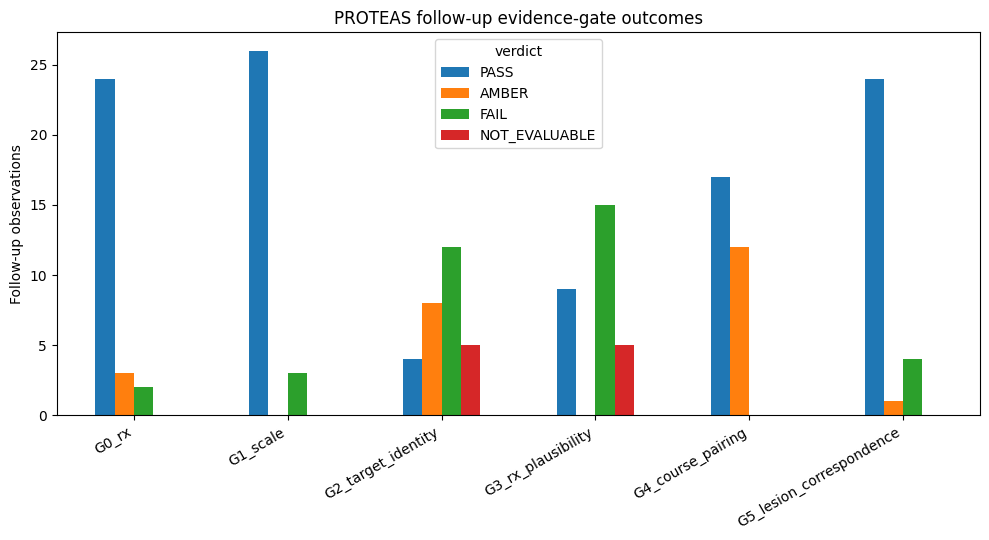

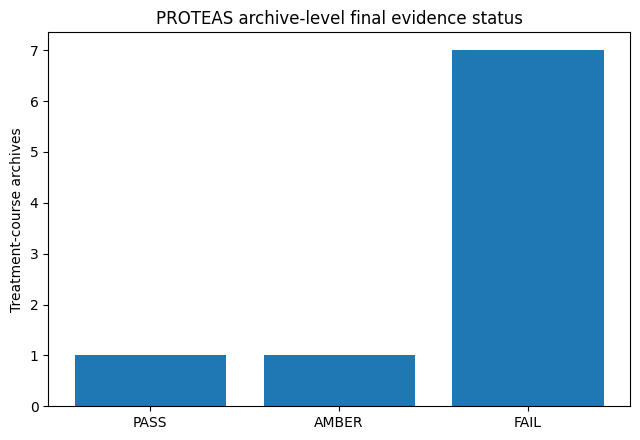

Saved: /content/FPOI_V75_G0_G5_POSTDIAGNOSTIC_FINAL/results/Fig_PROTEAS_followup_gate_outcomes.png
Saved: /content/FPOI_V75_G0_G5_POSTDIAGNOSTIC_FINAL/results/Fig_PROTEAS_archive_level_status.png


In [15]:
import matplotlib.pyplot as plt

gate_cols = [
    "gate_G0_rx","gate_G1_scale","gate_G2_target_identity",
    "gate_G3_rx_plausibility","gate_G4_course_pairing",
    "gate_G5_lesion_correspondence"
]

observed_states = [
    state for state in ["PASS","AMBER","FAIL","NOT_EVALUABLE"]
    if any(state in set(follow[g].dropna().astype(str)) for g in gate_cols)
]

plot_rows = []
for g in gate_cols:
    vc = follow[g].value_counts()
    for verdict in observed_states:
        plot_rows.append({
            "gate": g.replace("gate_",""),
            "verdict": verdict,
            "count": int(vc.get(verdict, 0))
        })

plot_df = pd.DataFrame(plot_rows)
pivot = plot_df.pivot(index="gate", columns="verdict", values="count").fillna(0)
pivot = pivot[[c for c in observed_states if c in pivot.columns]]

fig, ax = plt.subplots(figsize=(10,5.5))
pivot.plot(kind="bar", ax=ax)
ax.set_ylabel("Follow-up observations")
ax.set_xlabel("")
ax.set_title("PROTEAS follow-up evidence-gate outcomes")
plt.xticks(rotation=30, ha="right")
fig.tight_layout()
gate_fig = OUT/"Fig_PROTEAS_followup_gate_outcomes.png"
fig.savefig(gate_fig, dpi=300, bbox_inches="tight")
plt.show()

# Separate archive-level figure: the independent treatment-course unit.
arc = archive_summary["archive_overall_verdict"].value_counts()
fig, ax = plt.subplots(figsize=(6.5,4.5))
ordered = [s for s in ["PASS","AMBER","FAIL"] if s in arc.index]
ax.bar(ordered, [arc[s] for s in ordered])
ax.set_ylabel("Treatment-course archives")
ax.set_title("PROTEAS archive-level final evidence status")
fig.tight_layout()
arc_fig = OUT/"Fig_PROTEAS_archive_level_status.png"
fig.savefig(arc_fig, dpi=300, bbox_inches="tight")
plt.show()

# G1 diagnostic/support comparison export.
scale_cols = [
    c for c in ev.columns
    if c.startswith("archive_scale_max_pass_") or c in [
        "ratio_max_over_max","ratio_p999_over_p999","ratio_p999_over_max_v74"
    ]
]
ev[["archive_id","mask_role"] + scale_cols].to_csv(
    OUT/"scale_sensitivity_extract.csv", index=False
)

print("Saved:", gate_fig)
print("Saved:", arc_fig)


## 11. Package the frozen audit results back to Google Drive

Only the compact audit package needs to be returned to ChatGPT. The large PROTEAS archives stay in Drive.


In [16]:
shutil.copy2(GATES_FILE, OUT/"gates_v4_postdiagnostic_clean.json")
shutil.copy2(AUDIT_SCRIPT, OUT/"proteas_target_pairing_audit_v6.py")
shutil.copy2(MANIFEST, OUT/"manifest_final.csv")
shutil.copy2(PROVENANCE, OUT/"postdiagnostic_provenance.json")
shutil.copy2(G5_QA_PATH, OUT/"lesion_correspondence_QA.csv")
if (WORK/"g5_alignment_report.csv").exists():
    shutil.copy2(WORK/"g5_alignment_report.csv", OUT/"g5_alignment_report.csv")

README = f"""# FPOI V7.5 PROTEAS post-diagnostic clean rerun

Corrected gate-set provenance (authoritative config = gates_v4_postdiagnostic_clean.json):
{CORRECTED_GATES_GIT_COMMIT}

Corrected gate SHA-256:
{hashlib.sha256(GATES_FILE.read_bytes()).hexdigest()}

Manifest SHA-256:
{hashlib.sha256(MANIFEST.read_bytes()).hexdigest()}

G5 source:
{g5_source}

Clinical source:
{clinical_path}

Interpretation:
- G0–G4 are archive/course-level gates inherited by follow-up observations.
- G5 is observation-level.
- `gate_evidence.csv` uses `baseline_*` names for inherited baseline metrics.
- Report archive-level status as the independent unit, with follow-up counts as nested observations.
- This gate set was corrected after diagnostic inspection and is not claimed to be prespecified.
"""

(OUT/"README_AUDIT.md").write_text(README, encoding="utf-8")

zip_path = Path("/content/FPOI_V7_5_PROTEAS_G0_G5_POSTDIAGNOSTIC_CLEAN_RESULTS.zip")
if zip_path.exists():
    zip_path.unlink()

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for p in sorted(OUT.rglob("*")):
        if p.is_file():
            z.write(p, p.relative_to(OUT))

drive_target = RESULTS_DRIVE / zip_path.name
shutil.copy2(zip_path, drive_target)

print("Saved corrected result package to Google Drive:")
print(drive_target)
print("Upload this small ZIP back to ChatGPT.")


Saved corrected result package to Google Drive:
/content/drive/MyDrive/FPOI_DATA/RESULTS/PROTEAS_G0_G5_POSTDIAGNOSTIC_FINAL/FPOI_V7_5_PROTEAS_G0_G5_POSTDIAGNOSTIC_CLEAN_RESULTS.zip
Upload this small ZIP back to ChatGPT.
